In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
graph = run["connectivity_map"]
umap = run["umap"]
paris = ds.run_paris_clustering(graph, n_clusters=15)

Downloading bucket files: 56073178 / 56073178 complete

Downloading bytes: 56073178 / 56073178 complete

In [2]:
paris_result = ds.load_paris_clustering(paris)
pd.Series(paris_result.labels).value_counts().sort_index()

1     914
2     386
3     378
4     377
5     362
6     333
7     251
8     245
9     228
10    181
11    146
12     76
13     28
14     20
15     15
Name: count, dtype: int64

In [3]:
sampling = ds.run_topacedo_sampler(
    graph,
    paris,
    max_sampling_rate=0.1,
)
sampling_data = ds.load_artifact(sampling)
sampled = np.asarray(sampling_data["sampled"][:], dtype=bool)
seeds = np.asarray(sampling_data["seeds"][:], dtype=bool)
density = np.asarray(sampling_data["density"][:])
mean_snn = np.asarray(sampling_data["mean_snn"][:])
{
    "cells": int(sampled.size),
    "selected": int(sampled.sum()),
    "seeds": int(seeds.sum()),
}

INFO: 382 cells (9.70%) sub-sampled. Subsample to Seed (166 cells) ratio: 2.301


Constructing graph from dendrogram: 3939 / 3939 complete

{'cells': 3940, 'selected': 382, 'seeds': 166}

In [4]:
summary = pd.DataFrame(
    {
        "cluster": paris_result.labels,
        "sampled": sampled,
        "seed": seeds,
        "density": density,
        "mean_snn": mean_snn,
    }
)
summary.groupby("cluster", sort=True).agg(
    cells=("sampled", "size"),
    selected=("sampled", "sum"),
    seeds=("seed", "sum"),
    mean_density=("density", "mean"),
    mean_snn=("mean_snn", "mean"),
)

,cells,selected,seeds,mean_density,mean_snn
cluster,,,,,
1,914,48,18,1673.655411,2.497702
2,386,27,12,1507.801353,2.670725
3,378,39,17,1360.298351,3.445238
4,377,48,22,1267.171122,4.030769
5,362,41,17,1369.891701,3.811878
6,333,33,15,1369.199449,3.696396
7,251,37,14,1323.488924,4.062151
8,245,34,19,1220.276861,4.745714
9,228,22,8,1497.169502,4.028509


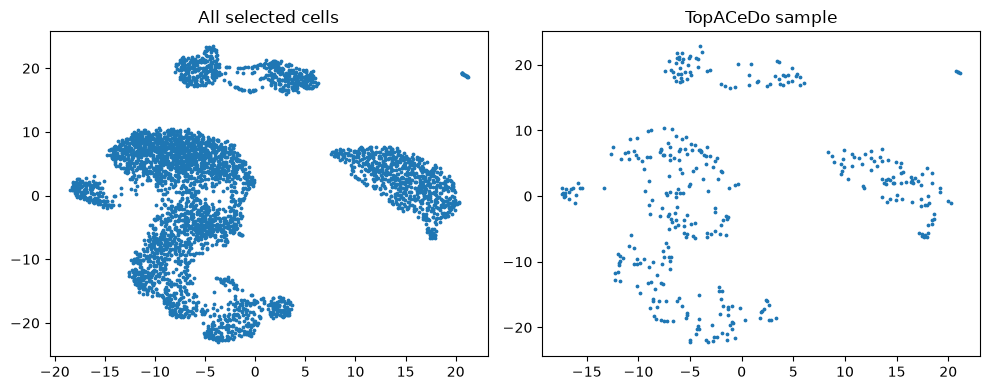

In [5]:
coordinates = np.asarray(ds.load_artifact(umap)["values"][:])
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(coordinates[:, 0], coordinates[:, 1], s=3)
axes[0].set_title("All selected cells")
axes[1].scatter(coordinates[sampled, 0], coordinates[sampled, 1], s=3)
axes[1].set_title("TopACeDo sample")
figure.tight_layout()

In [6]:
graph_cell_indices = np.flatnonzero(run.cells.fetch_all("I"))
sampled_cell_indices = graph_cell_indices[sampled]

export_directory = TemporaryDirectory()
subset_path = Path(export_directory.name) / "subset.zarr"
writer = scarf.SubsetZarr(
    zarr_loc=str(subset_path),
    assays=[ds.RNA],
    cell_idx=sampled_cell_indices,
    reset_cell_filter=False,
    overwrite_existing_file=True,
)
writer.dump()

subset = scarf.DataStore(str(subset_path))
subset.cells.N, subset.RNA.feats.N

(382, 33538)